## What is Clustering?

Clustering = making groups.

K-Means is an unsupervised machine-learning algorithm used to divide data into K clusters.

The important word is K.

K means:

How many clusters do we want?

For example:

K = 2

Cluster 1

Cluster 2

K = 3

Cluster 1

Cluster 2

Cluster 3

So when you see:

KMeans(n_clusters=3)

it simply means:

"Create 3 clusters."

### Why "Means"?

Why "Means"?

Because K-Means calculates the mean/average position of the points in a cluster.

That average position becomes the centroid.

### What is a Centroid?

A centroid = center of a cluster.

Imagine:
```
       ●
   ●       ●
       X
   ●       ●
       ●
```

X represents the centroid.

Think:

Cluster = group of points

Centroid = center of that group

For example:

Points:

10
20
30

Mean:

(10 + 20 + 30) / 3

= 20

So:

Centroid = 20

With two features, the centroid also has two values.

For example:
```
Age	Income
20	20,000
25	25,000
30	30,000
```
Centroid:

Age = 25

Income = 25,000

### The Entire K-Means Idea

Memorize this flow:
```
              K-Means

                 ↓
          Choose number K
                 ↓
       Initialize centroids
                 ↓
        Calculate distances
                 ↓
       Assign points to
       nearest centroid
                 ↓
       Calculate new centroids
                 ↓
              Repeat
                 ↓
       Final clusters

### The big question is:

How do we decide the best value of K?

```
1. Why do we need to find K?

Imagine we have customer data.

We could tell K-Means:

K = 2

and it will make 2 clusters.

Or:

K = 5

and it will make 5 clusters.

But what if the data naturally has 3 groups?

We don't want to randomly choose.

So we need a method to help us decide.

That's where:

WCSS

comes in.

### What is WCSS?

WCSS stands for:

Within-Cluster Sum of Squares

WCSS measures how close the points are to the centroid of their cluster.

Imagine one cluster:
```
        ●
    ●   ●   ●
        X
        ●
```
X = centroid.

If the points are very close to X:

WCSS = LOW

If the points are spread far away:

WCSS = HIGH

So:

Lower WCSS = tighter clusters

### Why "Sum of Squares"?
```
For every point, we calculate its distance from its cluster's centroid.

Suppose:

Centroid = 10

and our points are:

8
9
10
12

Distances from centroid:

10-8  → 2
10-9  → 1
10-10 → 0
10-12 → 2

We square the distances:

2² = 4
1² = 1
0² = 0
2² = 4

Then add them:

4 + 1 + 0 + 4 = 9

That is the basic idea behind WCSS.

More formally:

WCSS = Sum of squared distances between each point and its cluster centroid.
```
### What happens when K increases?
```
Suppose we have:

K = 1

Everything is placed into one cluster.

● ● ● ● ● ● ● ●
        X

The points may be far from the centroid.

Therefore:

WCSS is large.

K = 2

Now we have two centroids.

● ● ● ●        ● ● ● ●
    X              X

The points are closer to their respective centroids.

So:

WCSS decreases.

K = 3

Even more clusters:

● ●      ● ●      ● ● ●
 X        X          X

Points become even closer to their centroids.

Therefore:

WCSS decreases again.

K = 10

We have lots of clusters.

The points can become extremely close to their centroids.

Therefore:

WCSS becomes very small.

### Important Rule
```
As K increases:

WCSS will always decrease or stay the same.

Something interesting happens here.

If we simply chose the K with the lowest WCSS, we'd eventually choose a ridiculous number of clusters.

For example:

K = 1 → WCSS = 1000
K = 2 → WCSS = 600
K = 3 → WCSS = 350
K = 4 → WCSS = 220
K = 5 → WCSS = 150
K = 6 → WCSS = 100
K = 7 → WCSS = 70
K = 8 → WCSS = 50

Obviously, we don't want to create 8 clusters just because the WCSS is smaller.

We need to find the point where increasing K stops giving us a large improvement.

That's the:

Elbow Method

### What is the Elbow Method?
```
We calculate WCSS for different values of K.

For example:

K       WCSS
1       1000
2       600
3       350
4       300
5       270
6       250

Then we make a graph:

WCSS
 │
1000│●
    │ \
 600│  ●
    │   \
 350│    ●
    │     \
 300│      ●
    │       ●
 250│        ●
    └──────────────── K
      1  2  3  4  5  6

At first WCSS drops dramatically.

Then the improvement becomes smaller.

The bend looks like an elbow.

If the elbow occurs around:

K = 3

we choose:

K = 3

# Elbow Method
```
wcss = [] # It creates an empty list, We'll store the WCSS value for every K.

for i in range(1, 11): 
    kmeans = KMeans(           # We're creating a K-Means model.
        n_clusters=i,
        random_state = 42,
        n_init=10
    )
    kmeans.fit(X_scaled) # This tells K-Means: "Learn the clusters from my data X."

    wcss.append(kmeans.inertia_) # kmeans.inertia_ : This gives us the WCSS & 

After the loop, we might have:

wcss = [
    1000,
    600,
    350,
    300,
    270,
    250,
    ...
]

Then We Plot It

Your code:

plt.plot(range(1, 12), wcss)

means:

X-axis → K values
Y-axis → WCSS

Then:

plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

creates the graph.

You'll look for the elbow.

🧠 What you should remember

Don't memorize the whole paragraph. Remember this chain:
```
K-Means
   ↓
Need to choose K
   ↓
Try different K values
   ↓
Calculate WCSS for each K
   ↓
Plot K vs WCSS
   ↓
Find the "elbow"
   ↓
Choose K
   ↓
Train final K-Means model

And the most important relationship:

WCSS tells us how tightly packed our clusters are.

Elbow Method helps us choose a reasonable K.

Next: Actually creating the clusters

Now we'll take the chosen K and learn:

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

y_kmeans = kmeans.predict(X)

# K-Means Clustering Project

#### Customer Segmentation
```
Project goal

We have customer information such as:

Age
Annual Income
Spending Score

We want to discover different types of customers without having a target column.

For example, we may eventually discover groups like:

Cluster 0 → Low income + low spending
Cluster 1 → High income + high spending
Cluster 2 → High income + low spending
Cluster 3 → Low income + high spending

The important point is that we don't give these categories to K-Means. The algorithm discovers the groups.

# Project Roadmap

We'll build the project in these stages:
```
1. Problem Statement
       ↓
2. Import Libraries
       ↓
3. Load Dataset
       ↓
4. Understand the Dataset
       ↓
5. Data Cleaning
       ↓
6. Exploratory Data Analysis
       ↓
7. Select Features
       ↓
8. Feature Scaling
       ↓
9. Find Optimal K
       ↓
10. Elbow Method
       ↓
11. Train K-Means
       ↓
12. Get Cluster Labels
       ↓
13. Visualize Clusters
       ↓
14. Understand Each Cluster
       ↓
15. Business Interpretation
       ↓
16. Final Conclusion

# Step 1: Problem Statement

# Customer Segmentation using K-Means Clustering

## Problem Statement

A company has information about its customers, such as their age,
annual income, and spending score.

The company wants to understand its customers better and divide them
into different groups based on their characteristics and behavior.

Since the dataset does not contain a target variable, we will use
Unsupervised Machine Learning.

We will use the K-Means Clustering algorithm to identify groups of
similar customers.

## Project Objective

The main objectives of this project are:

1. Understand the customer dataset.
2. Perform basic data preprocessing.
3. Explore relationships between customer features.
4. Use the Elbow Method to find a suitable number of clusters.
5. Apply K-Means Clustering.
6. Assign each customer to a cluster.
7. Visualize the clusters.
8. Understand the characteristics of each customer group.
9. Draw useful business conclusions from the clusters.

In [97]:
import numpy as np # Numerical calculations
import pandas as pd # Working with datasets
import matplotlib.pyplot as plt # Creating graphs
import seaborn as sns # Better-looking statistical visualizations

from sklearn.cluster import KMeans # Our clustering algorithm
from sklearn.preprocessing import StandardScaler # Feature scaling

import warnings
warnings.filterwarnings("ignore")

In [98]:
data = pd.read_csv("Mall_Customers.csv") # Load the dataset

In [99]:
data.head() # This shows the first five rows.

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Step 4: Understand the Dataset

In [100]:
data.shape # (number of rows, number of columns)

(200, 5)

In [101]:
data.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [102]:
data.info()

# This helps us understand:

# Number of observations
# Columns
# Data types
# Missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [103]:
data.describe() 


# This gives:

# Count
# Mean
# Standard deviation
# Minimum
# Maximum
# Quartiles

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [104]:
data.isnull().count() # Check Missing Values

CustomerID                200
Genre                     200
Age                       200
Annual Income (k$)        200
Spending Score (1-100)    200
dtype: int64

# Step 6: Understand the Features
```
For our clustering, we need to decide:

Which columns should K-Means use?

We don't necessarily use every column.

For example:

CustomerID

is just an identifier.

It doesn't tell us anything meaningful about customer behavior.

So we shouldn't use it for clustering.

Similarly, Gender is categorical, while basic K-Means works naturally with numerical features.

We might choose:

Annual Income
Spending Score

for our first model.

# Step 7: Create X

.iloc : iloc means integer-location based indexing.

It lets you select rows and columns using their position numbers.

Remember, Python starts counting from 0:

So:

data.iloc [ : , [ 3 , 4 ] ] 

means:

Give me all rows and columns at positions 3 and 4.

In [105]:
X = data.iloc[:, [3,4]].values # is commonly used in Machine Learning, especially when selecting specific columns from a dataset.

```
This selects:

Annual Income
Spending Score

So now:

X
 ↓
Features used for K-Means

This is important:

X contains the information K-Means will use to find groups.

There is no y target variable here.

# Step 8: Visualize Before Clustering

Before applying Machine Learning, let's see what our data looks like.

In [106]:
data.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

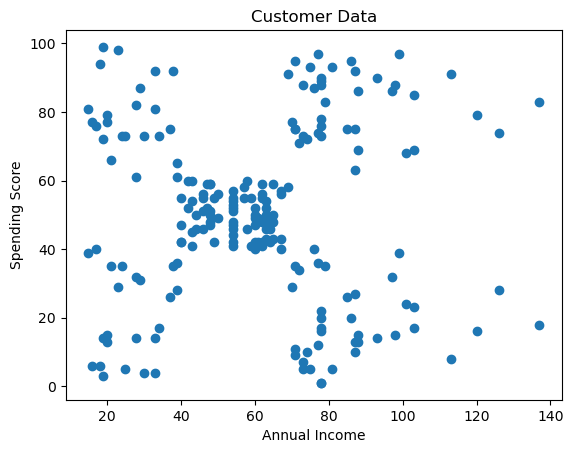

In [107]:
plt.scatter(X[:,0], X[:, 1])

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Data")

plt.show()

This is why visualization is useful.

We can see patterns before asking the algorithm to find them.

# Step 9: Feature Scaling

Now comes an important concept.

K-Means uses distance.

If one feature has a much larger numerical range than another, it can dominate the distance calculation.

So we can scale our features:

________________________________________
# What is Feature Scaling?
```
Feature Scaling means bringing different features into a similar range or scale.

Suppose your dataset has:

Age	Salary
20	20,000
30	50,000
40	80,000
50	1,00,000

Here:

Age ranges from 20–50
Salary ranges from 20,000–1,00,000

The numbers are on very different scales.

Feature scaling transforms them so that one feature doesn't unnecessarily dominate another.

Simple idea

Before scaling:

Age       → 20, 30, 40, 50
Salary    → 20,000, 50,000, 80,000, 1,00,000

After scaling:

Age       → 0.2, 0.4, 0.6, 0.8
Salary    → 0.1, 0.4, 0.7, 1.0

The actual values change, but the relative information is preserved.

```
## How Does Feature Scaling Work?
```
There are several methods, but two very common ones are:

A. Standardization

Also called Z-score normalization.

Formula:

z = x - mean / standard deviation

Where:

x = original value
μ = mean of the feature
σ = standard deviation

After standardization:

Mean ≈ 0
Standard deviation ≈ 1

Example:

Suppose:

Mean = 50
Standard deviation = 10

For:

x = 70

Then:

z = 70-50/10
z = 2

So 70 becomes 2 after scaling.

In Python:

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X = sc.fit_transform(X)
```
## 4. Min-Max Scaling
```
Another popular method is Min-Max Scaling.

Formula:

x' = x - x_min / x_max - x_min

This generally converts values into a range of:

0 → 1

Example:

Suppose:

Minimum = 10
Maximum = 50
Value = 30

Then:

x' = 30-10 / 50-10 
x' = 20 /40 
x' = 0.5

So:

30 → 0.5

In Python:

from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler()

X = sc.fit_transform(X)



In [108]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Now the features are on a comparable scale.
```
Think:

Original Data
      ↓
StandardScaler
      ↓
Scaled Data
      ↓
K-Means

# Step 10: Find the Best K

Now we face the big question:

How many clusters should we create?

We don't just randomly pick K = 3 because three looks aesthetically pleasing.

We'll use the Elbow Method.

### Calculate WCSS

In [109]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # kmeans.inertia_ :  WCSS tells us how tightly grouped our clusters are.

# Step 11: Plot the Elbow

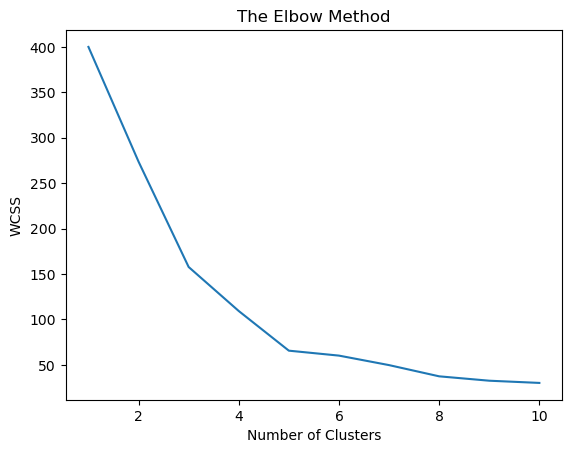

In [110]:
plt.plot(range(1, 11), wcss)

plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

# We'll look for the point where the curve starts to bend.

# Step 12: Train the Final K-Means Model

Suppose our elbow tells us:

K = 5

Then

In [111]:
kmeans = KMeans(
    n_clusters = 5,
    random_state = 42
    )
kmeans.fit(X_scaled)

# Now K-Means has learned the clusters.

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


# Step 13: Get Cluster Labels

In [112]:
y_kmeans = kmeans.labels_

```
For example:

[2, 3, 1, 3, 2, 0, 4, 1, ...]

Each number tells us which cluster that customer belongs to.

For example:

Customer 1 → Cluster 2
Customer 2 → Cluster 3
Customer 3 → Cluster 1

# Step 14: Get Centroids

In [113]:
kmeans.cluster_centers_

array([[-0.20091257, -0.02645617],
       [ 0.99158305,  1.23950275],
       [-1.32954532,  1.13217788],
       [ 1.05500302, -1.28443907],
       [-1.30751869, -1.13696536]])

This gives us the centers of the clusters.

Because we trained using scaled data, these centroid values are also in the scaled feature space.

If we want to interpret them in the original units, we'll later transform them back.

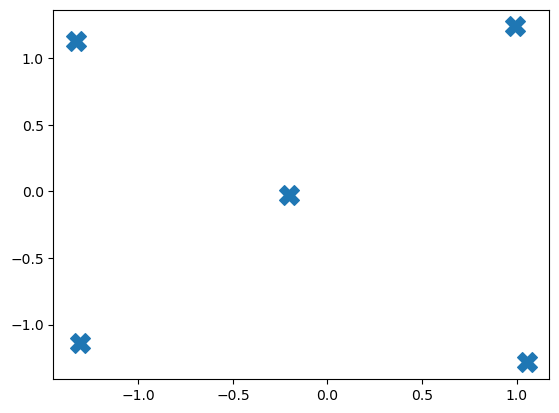

In [123]:
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200
)

# Step 15: Visualize the Final Clusters

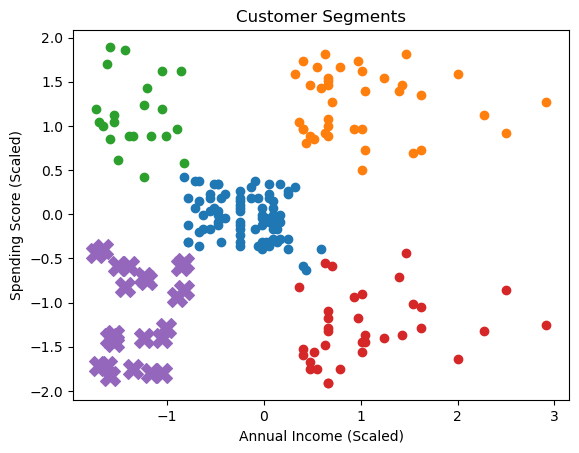

In [124]:
plt.scatter(
    X_scaled[y_kmeans == 0, 0],
    X_scaled[y_kmeans == 0, 1]
)

plt.scatter(
    X_scaled[y_kmeans == 1, 0],
    X_scaled[y_kmeans == 1, 1]
)

plt.scatter(
    X_scaled[y_kmeans == 2, 0],
    X_scaled[y_kmeans == 2, 1]
)

plt.scatter(
    X_scaled[y_kmeans == 3, 0],
    X_scaled[y_kmeans == 3, 1]
)

plt.scatter(
    X_scaled[y_kmeans == 4, 0],
    X_scaled[y_kmeans == 4, 1],
    marker="X",
    s=200
)

plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.title("Customer Segments")

plt.show()

We'll make this cleaner when we actually run the project.

# ⭐ One more important improvement

Instead of writing five separate plt.scatter() commands, we can eventually write this much more professionally:

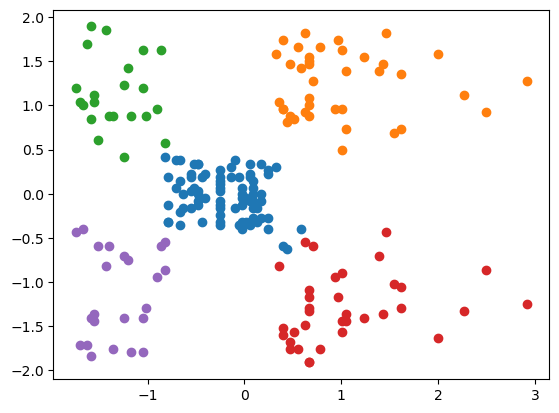

In [125]:
for i in range(5):
    plt.scatter(
        X_scaled[y_kmeans == i, 0],
        X_scaled[y_kmeans == i, 1]
    )

# Step 16: The Most Important Part

Getting a graph isn't the end of Data Science.

We need to ask:

What do these clusters actually mean?

For example, we could calculate the average characteristics of each cluster.

In [115]:
data["Cluster"] = y_kmeans

In [118]:
data.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Cluster'],
      dtype='object')

In [119]:
data.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


Now we can interpret them.
```
For example:

Cluster 0
Young + lower income + high spending
→ Potential impulsive/high-engagement customers

Cluster 1
Older + high income + low spending
→ High-income customers who aren't spending much

Cluster 3
High income + high spending
→ Valuable customers

This is where Machine Learning becomes useful to a business.
```
________________________________________________________________
```
🟢 Cluster 0
Age              ≈ 43
Annual Income    ≈ $55k
Spending Score   ≈ 50

These customers have:

Medium income
Medium spending
Middle/older age
Interpretation

Average / Moderate Customers

They aren't particularly high-value or low-value based on these two features.

🔵 Cluster 1
Age              ≈ 33
Annual Income    ≈ $87k
Spending Score   ≈ 82

These customers have:

High income
Very high spending
Relatively younger age
Interpretation

High-Value Customers

This is probably one of the most important groups for the business.

They have money and are willing to spend it.

🟡 Cluster 2
Age              ≈ 25
Annual Income    ≈ $26k
Spending Score   ≈ 79

These customers have:

Low income
Very high spending
Young age
Interpretation

Young High-Spending Customers

They don't earn much, but they spend a lot.

This could be an interesting segment for:

Discounts
Affordable products
Student/young-adult offers
Loyalty programs

🔴 Cluster 3
Age              ≈ 41
Annual Income    ≈ $88k
Spending Score   ≈ 17

These customers have:

Very high income
Very low spending
Older age
Interpretation

High-Income Low-Spending Customers

This is an interesting group.

They can afford to spend, but currently aren't spending much.

The business could potentially target them with:

Personalized offers
Premium product recommendations
Loyalty programs
Targeted marketing

🟣 Cluster 4
Age              ≈ 45
Annual Income    ≈ $26k
Spending Score   ≈ 21

These customers have:

Low income
Low spending
Older age
Interpretation

Low-Value / Low-Spending Customers

They have relatively low income and aren't spending much.

The business may not want to spend as much marketing budget targeting this group.
```
____________________________________________________________________
```
🧠 Our Final Customer Segments

We can summarize your actual results like this:

Cluster	Customer Type
0	Moderate Customers
1	High-Value Customers
2	Young High-Spending Customers
3	High-Income Low-Spending Customers
4	Low-Income Low-Spending Customers

Notice something important:

K-Means didn't give these names.

It only gave us:

0
1
2
3
4

We analyzed the averages and gave the clusters meaningful business interpretations.

That's an important Data Science skill.

# Step 17: Count Customers in Each Cluster
```
Now that K-Means has assigned every customer to a cluster, we will
count how many customers belong to each cluster.

This helps us understand the size of each customer segment.

In [130]:
cluster_counts = data["Cluster"].value_counts().sort_index()
cluster_counts

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

# Step 18: Put Everything Into One Summary Table

We will combine the average customer characteristics and the number
of customers in each cluster into one summary table.

This gives us a complete overview of our customer segments.

In [131]:
cluster_summary = data.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()

cluster_summary["Customer Count"] = cluster_counts

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100),Customer Count
Cluster,,,,
0,42.716049,55.296296,49.518519,81
1,32.692308,86.538462,82.128205,39
2,25.272727,25.727273,79.363636,22
3,41.114286,88.200000,17.114286,35
4,45.217391,26.304348,20.913043,23


# Step 19: Create Meaningful Segment Names 

### Naming the Customer Segments
```
The K-Means algorithm gives each cluster a numerical label.

These numbers do not have any business meaning.

Based on the characteristics of each cluster, we will assign
meaningful names to the customer segments.

In [132]:
cluster_names = {
    0: "Moderate Customers",
    1: "High-Value Customers",
    2: "Young High-Spending Customers",
    3: "High-Income Low-Spending Customers",
    4: "Low-Income Low-Spending Customers"
}

Now we apply these names:

In [133]:
data["Customer Segment"] = data["Cluster"].map(cluster_names)

In [134]:
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer Segment
0,1,Male,19,15,39,4,Low-Income Low-Spending Customers
1,2,Male,21,15,81,2,Young High-Spending Customers
2,3,Female,20,16,6,4,Low-Income Low-Spending Customers
3,4,Female,23,16,77,2,Young High-Spending Customers
4,5,Female,31,17,40,4,Low-Income Low-Spending Customers


# Step 20: Visualize Customer Distribution 

We will visualize the number of customers in each cluster.

This allows us to quickly compare the size of each customer segment.

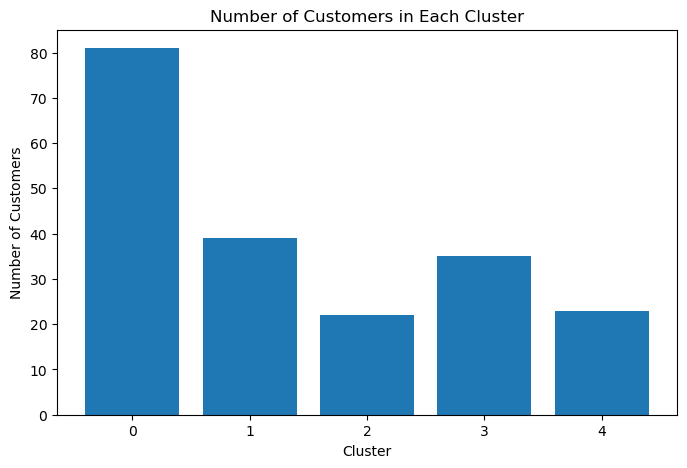

In [136]:
plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index,
    cluster_counts.values
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in Each Cluster")

plt.show()

This answers a simple question:

Which customer segment is the largest?

# Step 21: Better Visualization

Now let's create the main visualization of the project using the original values.

Remember, earlier we used:

X_scaled

for K-Means.

That's good for the algorithm.

But for humans, this:

Annual Income = 85k
Spending Score = 82

is much easier to understand than:

Annual Income = 1.42
Spending Score = 1.63

Humans, inconveniently, prefer meaningful numbers.

______________________________________________

We will visualize the customer clusters using the original
Annual Income and Spending Score values.

This makes the clusters easier to interpret from a business
perspective.

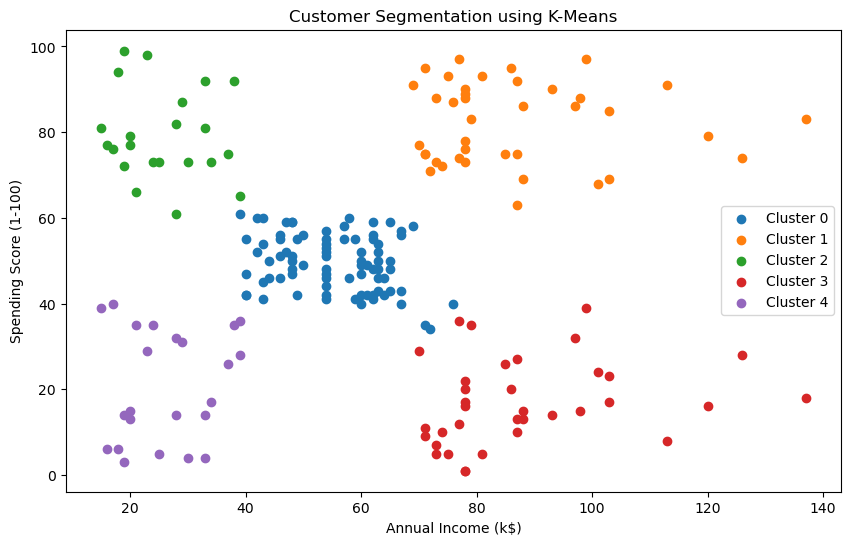

In [137]:
plt.figure(figsize=(10, 6))

for i in range(5):
    cluster_data = data[data["Cluster"] == i]

    plt.scatter(
        cluster_data["Annual Income (k$)"],
        cluster_data["Spending Score (1-100)"],
        label=f"Cluster {i}"
    )

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")
plt.legend()

plt.show()

# Step 22: Add Centroids to the Graph

In [139]:
kmeans.cluster_centers_

array([[-0.20091257, -0.02645617],
       [ 0.99158305,  1.23950275],
       [-1.32954532,  1.13217788],
       [ 1.05500302, -1.28443907],
       [-1.30751869, -1.13696536]])

contains the centroid positions.

But there is a small problem.

Those centroids were calculated using scaled data.

Therefore, they are also scaled.

We need to convert them back to the original scale.

This is a very useful concept.

In [140]:
centroids_original = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centroids_original

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

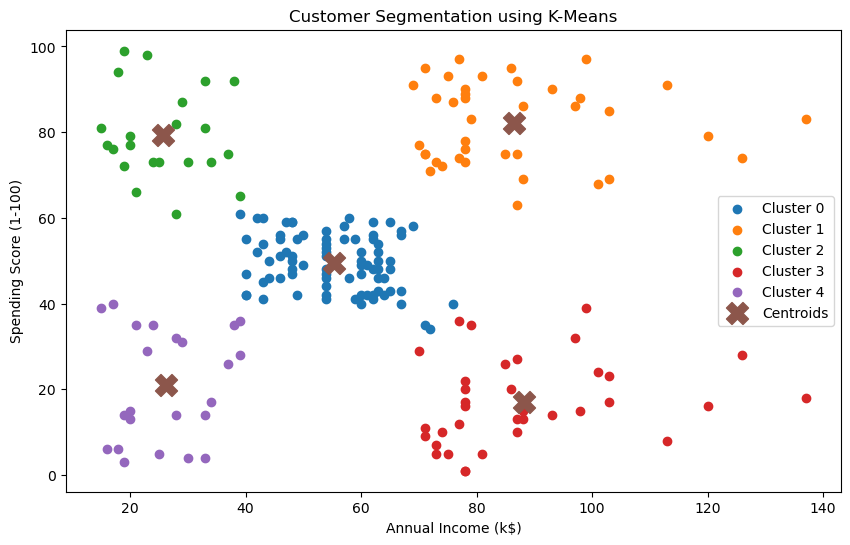

In [141]:
plt.figure(figsize=(10, 6))

for i in range(5):
    cluster_data = data[data["Cluster"] == i]

    plt.scatter(
        cluster_data["Annual Income (k$)"],
        cluster_data["Spending Score (1-100)"],
        label=f"Cluster {i}"
    )

# Plot centroids
plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    marker="X",
    s=250,
    label="Centroids"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")
plt.legend()

plt.show()

# Customer Segmentation using K-Means
```
## 1. Problem Statement

## 2. Import Libraries

## 3. Load Dataset

## 4. Understanding the Dataset
   - shape
   - columns
   - info
   - describe

## 5. Data Cleaning
   - missing values
   - duplicates
   - irrelevant columns

## 6. Exploratory Data Analysis
   - distributions
   - relationships
   - visualizations

## 7. Feature Selection

## 8. Feature Scaling

## 9. Finding Optimal K
   - WCSS
   - Elbow Method

## 10. Build K-Means Model

## 11. Cluster Labels

## 12. Cluster Centroids

## 13. Cluster Visualization

## 14. Cluster Analysis

## 15. Business Interpretation

## 16. Conclusion